In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import cv2
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/monkeytype/mt_dataset_catm.csv')
df.head()

,participant_id,brightness0,brightness1,brightness2,brightness3,local_symbol_cls0,local_symbol_cls1,local_symbol_cls2,local_symbol_cls3,correct_symbol_cls,correct_local_cls,participant_linspace,time_reaction_task,time_reaction_mean,chosen_local_cls
0,Jupiter,46.317761,35.222178,35.280851,52.363520,y,c,f,m,c,1,0.000000,1029,980.0,2
1,Jupiter,56.269372,30.205277,45.111926,39.408004,s,f,m,j,f,1,0.000593,579,980.0,1
2,Jupiter,55.413265,31.938776,35.726483,50.945871,c,y,j,m,j,2,0.001186,688,980.0,3
3,Jupiter,33.661432,37.567443,28.843033,48.010443,f,s,m,c,c,3,0.001779,578,980.0,1
4,Jupiter,64.207270,43.166454,26.046397,34.599649,s,y,j,m,m,3,0.002372,848,980.0,3


In [5]:
df_Jupiter = df[df['participant_id']=='Jupiter'].copy(deep=True)
df_Feliks = df[df['participant_id']=='Feliks'].copy(deep=True)
df_Yunt = df[df['participant_id']=='Yunt'].copy(deep=True)

In [6]:
df_part = df_Yunt

In [7]:
symbols_list = ['m', 'c', 's', 'y', 'f', 'j']
lsc_list = ['local_symbol_cls0',	'local_symbol_cls1',	'local_symbol_cls2',	'local_symbol_cls3']

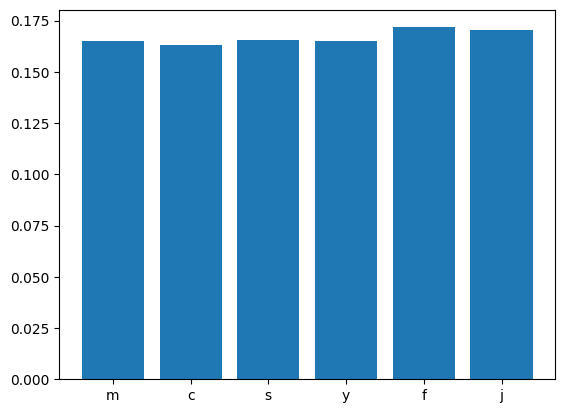

In [8]:
symbols_cols = symbols_list.copy()
n_rows = 1
df_sym_hist_all = pd.DataFrame(np.zeros((n_rows, len(symbols_cols))),columns=symbols_cols)
for index, row in df_part.iterrows():
  for s in lsc_list:
      symbol2count = df_part.loc[index, s]
      df_sym_hist_all.loc[0, symbol2count]+=1.0

dfshasum = df_sym_hist_all.sum(axis=1)[0]
df_sym_hist_all.iloc[0]/=dfshasum
values = df_sym_hist_all.iloc[0]
fig, ax = plt.subplots()
ax.bar(values.index, values.values, label=values.values)

plt.show()

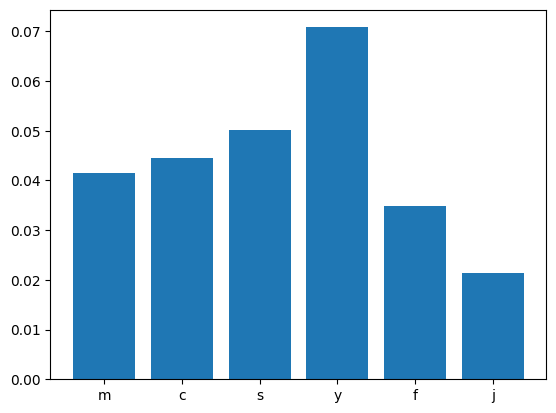

In [15]:
n_rows = 1
df_sym_hist1 = pd.DataFrame(np.zeros((n_rows, len(symbols_cols))),columns=symbols_cols)
for index, row in df_part.iterrows():
  index_corr = str(df_part.loc[index, 'correct_local_cls'])
  index_ch = str(df_part.loc[index, 'chosen_local_cls'])
  for s in lsc_list:
    if index_ch in s and index_ch == index_corr:
      symbol2count = df_part.loc[index, s]
      df_sym_hist1.loc[0, symbol2count]+=1.0

all_counts = df_part.shape[0]
values = df_sym_hist1.iloc[0]/all_counts
fig, ax = plt.subplots()
ax.bar(values.index, values.values, label=values.values)

plt.show()

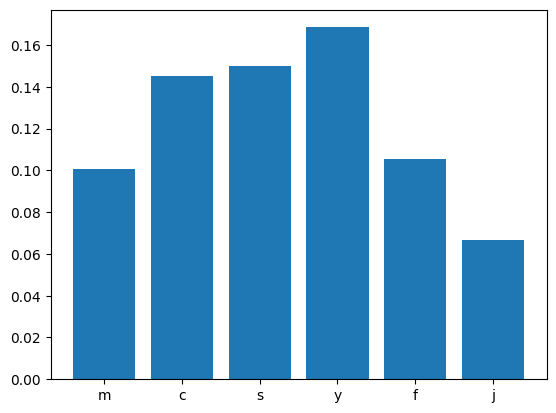

In [16]:
n_rows = 1
df_sym_hist0 = pd.DataFrame(np.zeros((n_rows, len(symbols_cols))),columns=symbols_cols)
for index, row in df_part.iterrows():
  index_corr = str(df_part.loc[index, 'correct_local_cls'])
  index_ch = str(df_part.loc[index, 'chosen_local_cls'])
  for s in lsc_list:
    if index_ch in s and index_ch != index_corr:
      symbol2count = df_part.loc[index, s]
      df_sym_hist0.loc[0, symbol2count]+=1.0

all_counts = df_part.shape[0]
values = df_sym_hist0.iloc[0]/all_counts
fig, ax = plt.subplots()
ax.bar(values.index, values.values, label=values.values)

plt.show()

In [14]:
p_s1 = 0
for index, row in df_part.iterrows():
  index_corr = str(df_part.loc[index, 'correct_local_cls'])
  index_ch = str(df_part.loc[index, 'chosen_local_cls'])
  if index_ch == index_corr:
      p_s1+=1.0
p_s1/=all_counts
p_s0 = 1.0 - p_s1

m    0.128283
c    0.098714
s    0.106367
y    0.130494
f    0.105267
j    0.102865
Name: 0, dtype: float64
0.6719911387488743


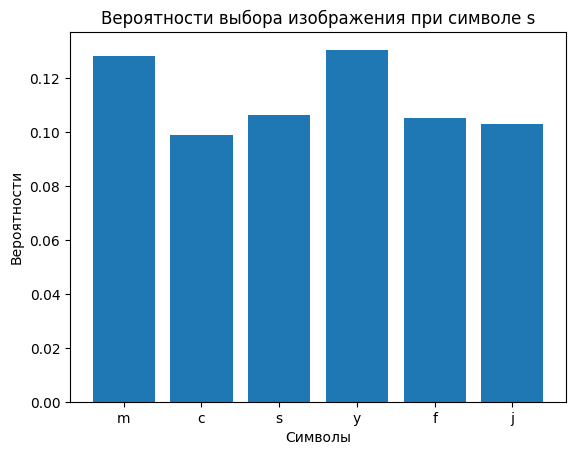

In [18]:
p_s1_b_var2 = ((df_sym_hist1.iloc[0]/all_counts) * p_s1 )/ ((df_sym_hist1.iloc[0]/all_counts)*p_s1 + (df_sym_hist0.iloc[0]/all_counts)*p_s0)
print(p_s1_b_var2)
print(np.sum(p_s1_b_var2))

values = p_s1_b_var2
fig, ax = plt.subplots()
ax.bar(values.index, values.values, label=values.values)
#plt.ylim(0, 0.20)
plt.xlabel("Символы")
plt.ylabel("Вероятности")
plt.title("Вероятности выбора изображения при символе s")
plt.show()

